In [1]:
import os; WORKDIR = f"{os.getcwd()}/.."
import sys; sys.path.append(f"{WORKDIR}/libPython")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ROOT

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.utils import shuffle
from DataManager import ArrayDataset

Welcome to JupyROOT 6.28/04


In [2]:
# input features
features = ["j1_energy", "j1_px", "j1_py", "j1_pz", "j1_chEmEF", "j1_chHEF", "j1_neEmEF", "j1_neHEF", "j1_muEF", "j1_btagDeepFlavB", "j1_btagDeepFlavQG",
            "j2_energy", "j2_px", "j2_py", "j2_pz", "j2_chEmEF", "j2_chHEF", "j2_neEmEF", "j2_neHEF", "j2_muEF", "j2_btagDeepFlavB", "j2_btagDeepFlavQG",
            "j3_energy", "j3_px", "j3_py", "j3_pz", "j3_chEmEF", "j3_chHEF", "j3_neEmEF", "j3_neHEF", "j3_muEF", "j3_btagDeepFlavB", "j3_btagDeepFlavQG",
            "j4_energy", "j4_px", "j4_py", "j4_pz", "j4_chEmEF", "j4_chHEF", "j4_neEmEF", "j4_neHEF", "j4_muEF", "j4_btagDeepFlavB", "j4_btagDeepFlavQG",
            "avg_deltaR", "Nj", "HT"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"@@@@ Using device {DEVICE}")

@@@@ Using device cuda


In [3]:
# load dataset
sigCSV = pd.read_csv(f"{WORKDIR}/DATA/TT/sample.csv", index_col=0); sigCSV["label"] = 1
bkgCSV = pd.read_csv(f"{WORKDIR}/DATA/QCD/sample.csv", index_col=0); bkgCSV["label"] = 0

sample = shuffle(pd.concat([sigCSV, bkgCSV], ignore_index=True), random_state=42)
trainset = sample[:int(len(sample)*0.6)]
validset = sample[int(len(sample)*0.6):int(len(sample)*0.7)]
testset = sample[int(len(sample)*0.7):]

trainLoader = DataLoader(ArrayDataset(trainset), batch_size=1024, pin_memory=True, shuffle=True)
validLoader = DataLoader(ArrayDataset(validset), batch_size=1024, pin_memory=True, shuffle=False)
testLoader  = DataLoader(ArrayDataset(testset), batch_size=1024, pin_memory=True, shuffle=False)

In [4]:
# make a simple DNN network
class SimpleDNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(SimpleDNN, self).__init__()
        self.bn0 = torch.nn.BatchNorm1d(in_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.dense1 = torch.nn.Linear(in_channels, hidden_channels, bias=True)
        self.dense2 = torch.nn.Linear(hidden_channels, hidden_channels, bias=True)
        self.output = torch.nn.Linear(hidden_channels, out_channels, bias=True)
        
    def forward(self, x):
        x = self.bn0(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.relu(self.dense1(x))
        x = self.bn1(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.relu(self.dense2(x))
        x = self.bn2(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.softmax(self.output(x), dim=1)
        
        return x

In [5]:
def train(model, optimizer):
    model.train()

    for data, label in trainLoader:
        data, label = data.to(DEVICE), label.to(DEVICE)
        out = model(data)
        loss = F.cross_entropy(out, label.view(len(label)))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def test(model, loader):
    model.eval()
    loss = 0.
    correct = 0.

    with torch.no_grad():
        for data, label in loader:
            data, label = data.to(DEVICE), label.to(DEVICE)
            out = model(data)
            pred = out.max(1, keepdim=True)[1]
            loss += F.cross_entropy(out, label.view(len(label)), reduction="sum").item()
            correct += pred.eq(label.view_as(pred)).sum().item()

    loss /= len(loader.dataset)
    correct /= len(loader.dataset)
    return (loss, correct)

In [6]:
model = SimpleDNN(len(features), 64, 2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
writer = SummaryWriter()
print(model)

for epoch in range(1, 31):
    train(model, optimizer)
    trainLoss, trainAcc = test(model, trainLoader)
    validLoss, validAcc = test(model, validLoader)
    writer.add_scalar("Loss/train", trainLoss, epoch)
    writer.add_scalar("Loss/valid", validLoss, epoch)
    writer.add_scalar("Acc/train", trainAcc, epoch)
    writer.add_scalar("Acc/valid", validAcc, epoch)

    print(f"[EPOCH {epoch}]\tTrain Acc: {trainAcc*100:.2f}\tTrain Loss: {trainLoss:.4e}")
    print(f"[EPOCH {epoch}]\tValid Acc: {validAcc*100:.2f}\tValid Loss: {validLoss:.4e}\n")
writer.flush()
writer.close()

SimpleDNN(
  (bn0): BatchNorm1d(47, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dense1): Linear(in_features=47, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=2, bias=True)
)
[EPOCH 1]	Train Acc: 87.57	Train Loss: 4.3375e-01
[EPOCH 1]	Valid Acc: 87.64	Valid Loss: 4.3354e-01

[EPOCH 2]	Train Acc: 88.06	Train Loss: 4.2806e-01
[EPOCH 2]	Valid Acc: 88.04	Valid Loss: 4.2800e-01

[EPOCH 3]	Train Acc: 88.23	Train Loss: 4.2598e-01
[EPOCH 3]	Valid Acc: 88.39	Valid Loss: 4.2535e-01

[EPOCH 4]	Train Acc: 88.47	Train Loss: 4.2392e-01
[EPOCH 4]	Valid Acc: 88.48	Valid Loss: 4.2368e-01

[EPOCH 5]	Train Acc: 88.45	Train Loss: 4.2422e-01
[EPOCH 5]	Valid Acc: 88.42	Valid Loss: 4.2378e-01

[EPOCH 6]	Train Acc: 88.69	

In [7]:
# model interpretation using integrated gradients
from captum.attr import IntegratedGradients, Saliency
from captum.attr import LayerConductance
from captum.attr import NeuronConductance

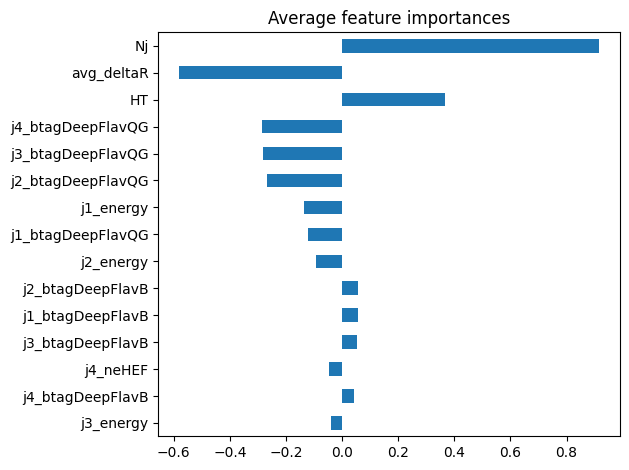

In [8]:
ig = IntegratedGradients(model)
# make test input tensors
X_valid, y_valid = validset.to_numpy()[:, :-1], validset.to_numpy()[:, -1]
X_valid, y_valid = torch.FloatTensor(X_valid).to(DEVICE), torch.LongTensor(y_valid).to(DEVICE)
X_valid.requires_grad_()
attr, delta = ig.attribute(X_valid, target=1, return_convergence_delta=True)
attr = attr.cpu().detach().numpy()

attributions = pd.DataFrame(attr, columns=features).T
attributions["mean"] = attributions.mean(axis=1)
attributions["std"] = attributions.std(axis=1)
attributions.sort_values(by=["mean"], key=lambda x: abs(x), inplace=True)

plt.figure()
attributions['mean'].iloc[-15:].plot.barh()
plt.title("Average feature importances")
plt.tight_layout()

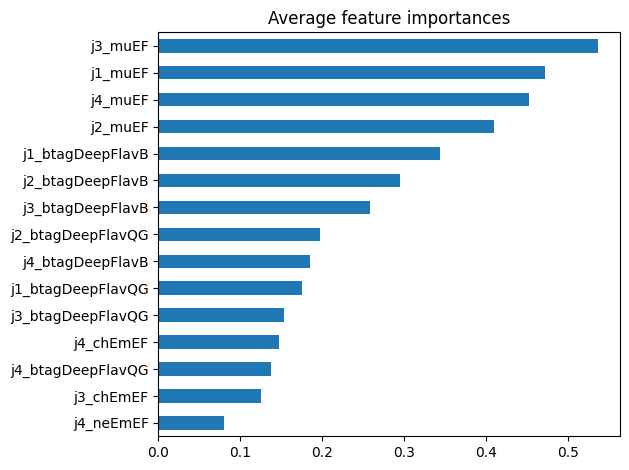

In [9]:
ig = Saliency(model)
# make test input tensors
X_valid, y_valid = validset.to_numpy()[:, :-1], validset.to_numpy()[:, -1]
X_valid, y_valid = torch.FloatTensor(X_valid).to(DEVICE), torch.LongTensor(y_valid).to(DEVICE)
X_valid.requires_grad_()
attr = ig.attribute(X_valid, target=1)
attr = attr.cpu().detach().numpy()

attributions = pd.DataFrame(attr, columns=features).T
attributions["mean"] = attributions.mean(axis=1)
attributions["std"] = attributions.std(axis=1)
attributions.sort_values(by=["mean"], key=lambda x: abs(x), inplace=True)

plt.figure()
attributions['mean'].iloc[-15:].plot.barh()
plt.title("Average feature importances")
plt.tight_layout()

In [14]:
ig = IntegratedGradients(model)
# make test input tensors
X_valid, y_valid = validset.to_numpy()[:, :-1], validset.to_numpy()[:, -1]
X_valid, y_valid = torch.FloatTensor(X_valid).to(DEVICE), torch.LongTensor(y_valid).to(DEVICE)
X_valid.requires_grad_()
attr, delta = ig.attribute(X_valid, target=1, return_convergence_delta=True)
attr = attr.cpu().detach().numpy()
attributions = pd.DataFrame(attr, columns=features)

h_flavB = ROOT.TH1D("flavB", "", 500, -5., 5.)
h_flavQG = ROOT.TH1D("flavQG", "", 500, -5., 5.)
for idx in attributions.index:
    if idx == 10000: break
    attributions.loc[idx, "j4_btagDeepFlavQG"]
    h_flavB.Fill(attributions.loc[idx, "j1_btagDeepFlavB"])
    h_flavQG.Fill(attributions.loc[idx, "j4_btagDeepFlavQG"])

Warning in <TROOT::Append>: Replacing existing TH1: flavB (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: flavQG (Potential memory leak).


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


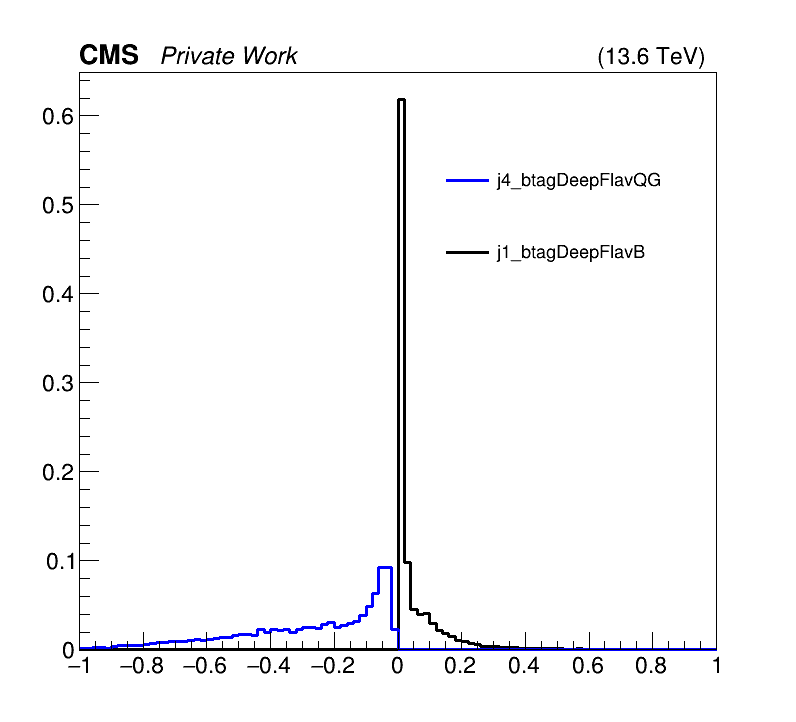

In [15]:
h_flavB.SetStats(0)
h_flavB.Scale(1./h_flavB.Integral())
h_flavB.SetLineColor(ROOT.kBlack); h_flavB.SetLineWidth(3)
h_flavB.GetXaxis().SetRangeUser(-1., 1.)

h_flavQG.Scale(1./h_flavQG.Integral())
h_flavQG.SetLineColor(ROOT.kBlue); h_flavQG.SetLineWidth(3)

legend = ROOT.TLegend(0.55, 0.6, 0.85, 0.8)
legend.SetFillStyle(0)
legend.SetBorderSize(0)
legend.AddEntry(h_flavQG, "j4_btagDeepFlavQG", "l")
legend.AddEntry(h_flavB, "j1_btagDeepFlavB", "l")

text = ROOT.TLatex()
def setCOMText():
    text.SetTextSize(0.035)
    text.SetTextFont(42)
    
def setCMSText():
    text.SetTextSize(0.04)
    text.SetTextFont(61)
    
def setWIPText():
    text.SetTextSize(0.036)
    text.SetTextFont(52)

c = ROOT.TCanvas("canvas", "", 800, 750)
c.cd()
h_flavB.Draw("hist")
h_flavQG.Draw("hist&same")
legend.Draw("same")
setCOMText(); text.DrawLatexNDC(0.75, 0.91, "(13.6 TeV)")
setCMSText(); text.DrawLatexNDC(0.1, 0.91, "CMS")
setWIPText(); text.DrawLatexNDC(0.2, 0.91, "Private Work")
c.RedrawAxis()
c.Draw()

In [16]:
# layer attribution
cond = LayerConductance(model, model.dense1)
cond_vals = cond.attribute(X_valid, target=1)
cond_vals = cond_vals.cpu().detach().numpy()

In [17]:
conductances = pd.DataFrame(cond_vals).T
conductances["mean"] = conductances.mean(axis=1)
conductances["std"] = conductances.std(axis=1)
conductances.sort_values(by=["mean"], key=lambda x: abs(x), inplace=True)

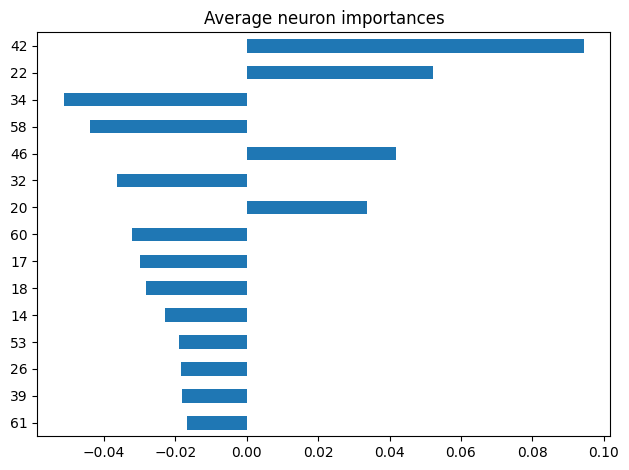

In [18]:
# top 15 activated neurons
plt.figure()
conductances['mean'].iloc[-15:].plot.barh()
plt.title("Average neuron importances")
plt.tight_layout()

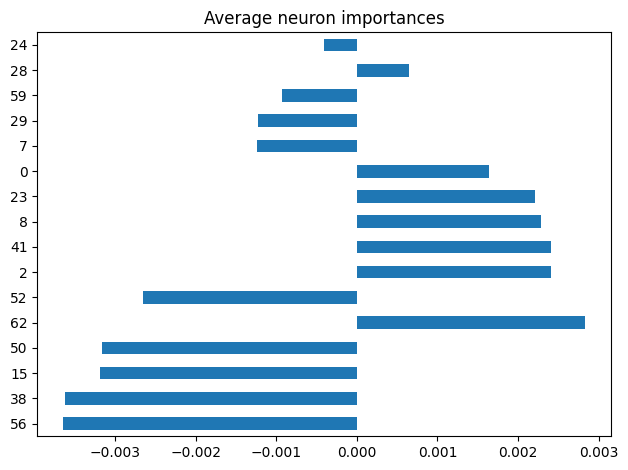

In [19]:
# bottom 15 activated neurons
plt.figure()
conductances['mean'][15::-1].plot.barh()
plt.title("Average neuron importances")
plt.tight_layout()

Text(0.5, 1.0, 'Neuron 42 distribution')

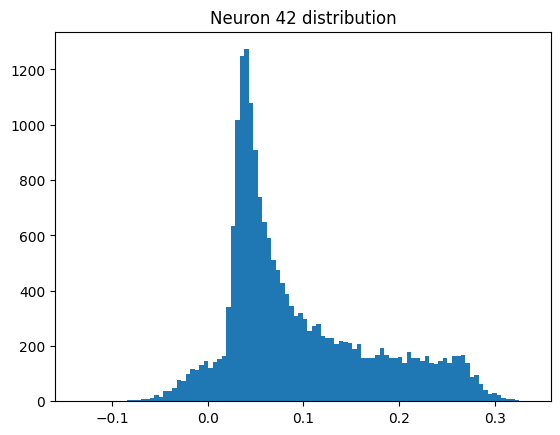

In [20]:
# the most activated neuron (42)
plt.figure()
plt.hist(cond_vals[:, 42], 100)
plt.title("Neuron 42 distribution")

Text(0.5, 1.0, 'Neuron 24 conductance distribution')

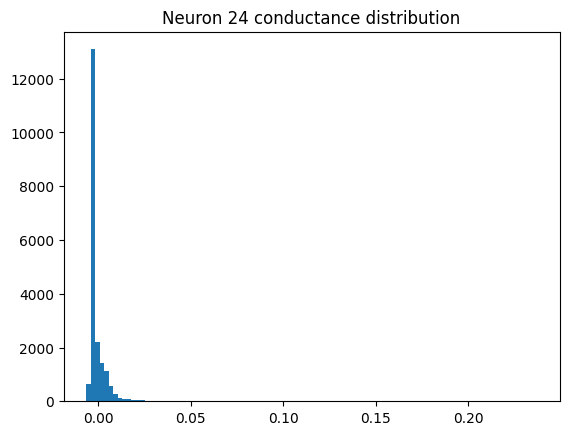

In [22]:
# the least activate neuron (neuron 24)
plt.figure()
plt.hist(cond_vals[:, 24], 100)
plt.title("Neuron 24 conductance distribution")

In [25]:
neuron_cond = NeuronConductance(model, model.dense1)
neuron_cond_vals_42 = neuron_cond.attribute(X_valid, neuron_selector=42, target=1); neuron_cond_vals_42 = neuron_cond_vals_42.cpu().detach().numpy()
neuron_cond_vals_24 = neuron_cond.attribute(X_valid, neuron_selector=24, target=1); neuron_cond_vals_24 = neuron_cond_vals_24.cpu().detach().numpy()

In [26]:
conductances_42 = pd.DataFrame(neuron_cond_vals_42, columns=features).T
conductances_42["mean"] = conductances_42.mean(axis=1)
conductances_42["std"] = conductances_42.std(axis=1)
conductances_42.sort_values(by=["mean"], key=lambda x: abs(x), inplace=True)

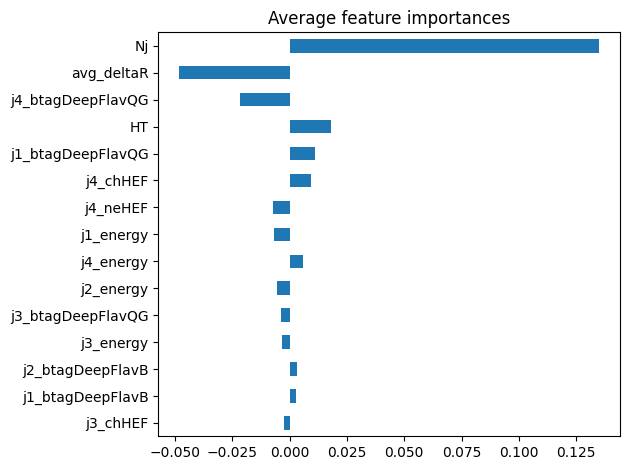

In [27]:
plt.figure()
conductances_42['mean'].iloc[-15:].plot.barh()
plt.title("Average feature importances")
plt.tight_layout()

In [28]:
conductances_24 = pd.DataFrame(neuron_cond_vals_24, columns=features).T
conductances_24["mean"] = conductances_24.mean(axis=1)
conductances_24["std"] = conductances_24.std(axis=1)
conductances_24.sort_values(by=["mean"], key=lambda x: abs(x), inplace=True)

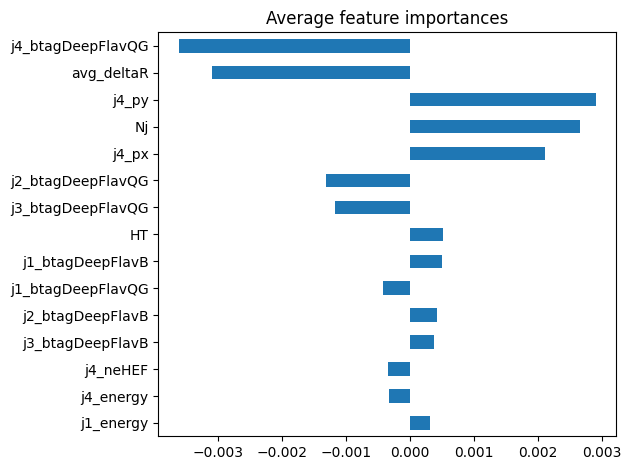

: 

In [29]:
plt.figure()
conductances_24['mean'].iloc[-15:].plot.barh()
plt.title("Average feature importances")
plt.tight_layout()